In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# import os
# os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

In [2]:
def f(x):
    return 3*x**2 -4*x +5

In [3]:
f(3)

20

In [4]:
x5 = np.arange(-5, 5,0.25)
x5

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(x5)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

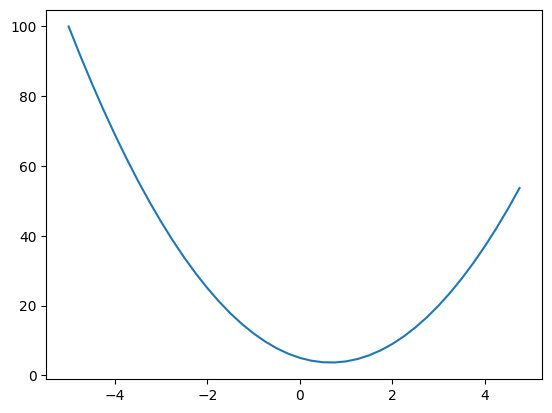

In [6]:
plt.plot(x5,ys)

In [7]:
h = 0.000001
x = 3
(f(x+h)-f(x))/h

14.000003002223593

In [8]:
h = 0.000001
x = -3
(f(x+h)-f(x))/h

-21.999997002808414

In [9]:
h = 0.0000001
x = 2/3
(f(x+h)-f(x))/h

2.9753977059954195e-07

In [10]:
a = 2
b = -3
c = 10
d = a * b +c
h = 0.00001 
d1 = a*b +c
a+=h
d2 = a*b+c

print(d1)
print(d2)
print("slope", (d2-d1)/h)

4
3.9999699999999994
slope -3.000000000064062


In [254]:
class Value:
    def __init__(self, data, _children = (), _op='', label =''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda:None
        self._op = _op
        self.grad = 0.0
        self.label= label


    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __radd__(self, other):
        return self+other
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1*out.grad
            other.grad += 1*out.grad
            #  = 1* out.grad

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other),'*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad* self.data
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self*other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad
          
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,), 'exp')
        def _backward():
            self.grad += out.data*out.grad

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        
        build_topo(self)
        self.grad = 1
        for node in reversed(topo):
            node._backward()    

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only Supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other*self.data**(other-1)*out.grad

        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * other**-1

    def __rsub__(self, other):
        return -self + other
    
    def __neg__(self):
        return self*-1

    def __sub__(self, other):
        return self+(-other)
    
    


a = Value(8, label = 'a')
b = Value(6.7, label = 'b')

In [12]:
a = Value(5)

In [13]:
a

Value(data=5)

In [14]:
a+b

Value(data=11.7)

In [15]:
print(a+b)
print(a*b)
print(a/b)
print(a-b)

Value(data=11.7)
Value(data=33.5)
Value(data=0.7462686567164178)
Value(data=-1.7000000000000002)


In [16]:
c = a+b
print(c)
print(c.data)
print(c._prev)
print(c._op)
d = a*b+c-a

Value(data=11.7)
11.7
{Value(data=6.7), Value(data=5)}
+


In [17]:
#AM NOT FOCUSING ON THIS

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(name=uid, label="{%s | %.4f | grad %.2f}"%(n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=uid +n._op, label= n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)
    return(dot)

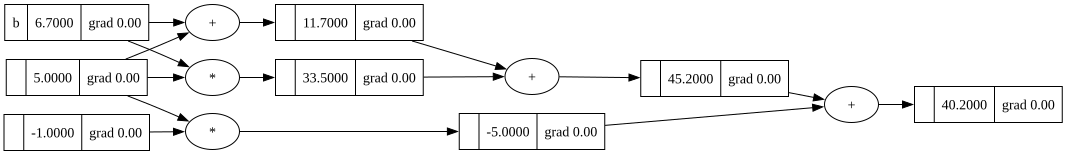

In [18]:
draw_dot(d)

In [19]:
a = Value(2, label = 'a')
b = Value(-3, label = 'b')
c = Value( 10, label = 'c')
e = a*b; e.label = 'e'
d = e+c; d.label='d'
f = Value(-2, label='f')
L = d*f; L.label = 'L'
L

Value(data=-8)

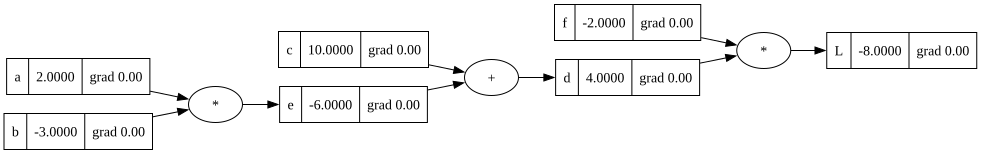

In [20]:
draw_dot(L)

In [21]:
def lol():
    a = Value(2, label = 'a')
    b = Value(-3, label = 'b')
    c = Value( 10, label = 'c')
    e = a*b; e.label = 'e'
    L3_e = e.data
    d = e+c; d.label='d'
    L2_d = d.data
    f = Value(-2, label='f')
    L = d*f; L.label = 'L'
    L=L.data
    
    #dL/d__
    a = Value(2, label = 'a')
    b = Value(-3, label = 'b')
    c = Value(10, label = 'c')
    e = a*b; e.label = 'e'
    d = e+c; d.label='d'
    d.data+=h
    f = Value(-2, label='f')
    L1 = d*f; L1.label = 'L'
    L1 = L1.data
    x = (L1-L)/h
    print((L1-L)/h)
    

    #dd/d__
    a = Value(2, label = 'a')
    b = Value(-3, label = 'b')
    c = Value(10+h, label = 'c')
    e = a*b; e.label = 'e'
    d = e+c; d.label='d'
    L2 = d.data
    y = (L2-L2_d)/h
    print((L2-L2_d)/h)

    #de/d_
    a = Value(2+h, label = 'a')
    b = Value(-3, label = 'b')
    c = Value(10+h, label = 'c')
    e = a*b; e.label = 'e'
    L3 = e.data
    L3_a = (L3-L3_e)/h
    print(L3_a)

    print(L3_a * y*x)
    print(x*y)
lol()
    

-1.9999999999242843
0.9999999999621422
-3.000000000064062
5.99999999967383
-1.9999999998485687


In [22]:
# dL/dc = (dL/dd)*(dd/dc)

In [23]:
L.grad = 1
d.grad = -2
f.grad = 4
e.grad = -2
c.grad = -2

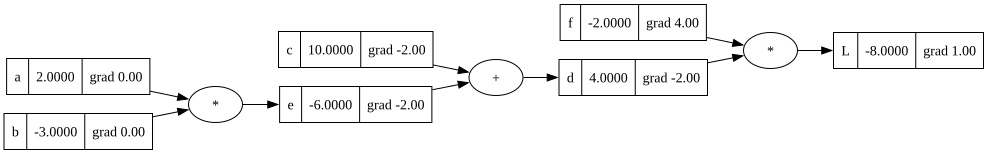

In [24]:
draw_dot(L)

In [25]:
# dL/ da = (dL/dd) * (dd/de) * (de/da) = 6

In [26]:
a.grad = e.grad*b.data
b.grad = e.grad*a.data

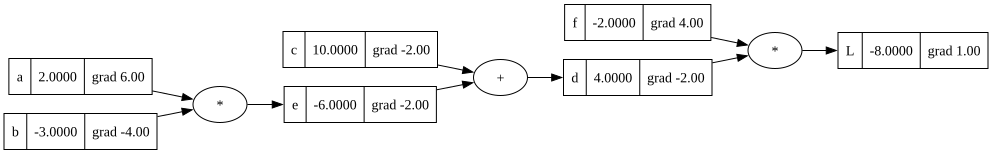

In [27]:
draw_dot(L)

In [28]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b
d = e+c
L = d*f
L.data

-7.286496

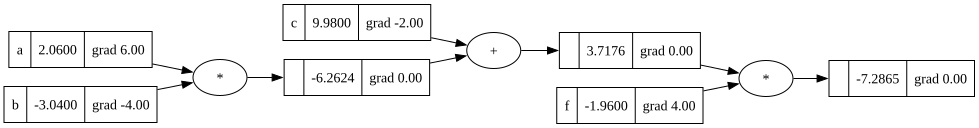

In [29]:
draw_dot(L)

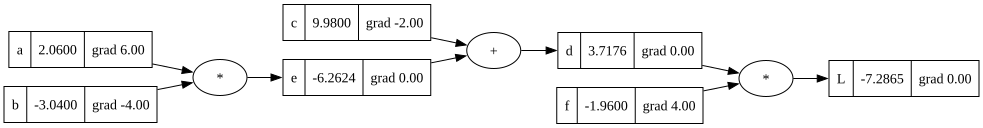

In [30]:
e.label='e'
d.label = 'd'
L.label = 'L'
draw_dot(L)

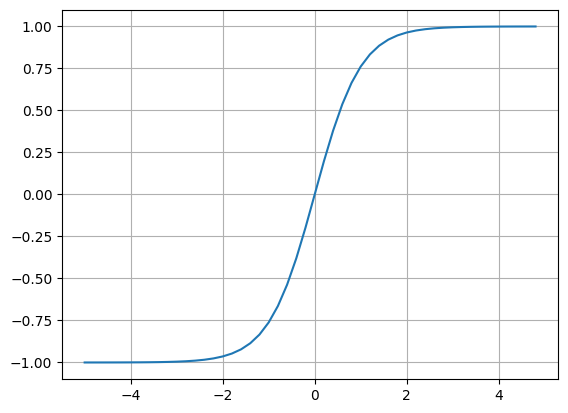

In [31]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

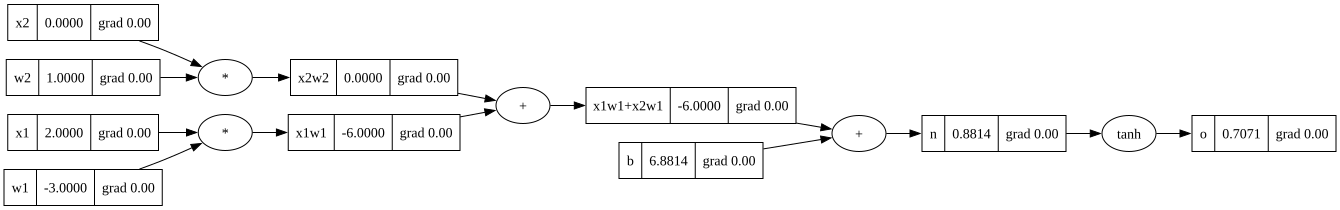

In [32]:
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')
w1 = Value(-3, label='w1')
w2 = Value(1, label = 'w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w1 = x1w1+x2w2; x1w1x2w1.label = 'x1w1+x2w1'
n = x1w1x2w1+b; n.label = 'n'
o = n.tanh()
o.label = 'o'
draw_dot(o)

In [33]:
o.grad = 1

In [34]:
# o = tanh(n)
#do/dn = 1- tanh^2(n) = 1-o^2
n.grad = 1- o.data**2

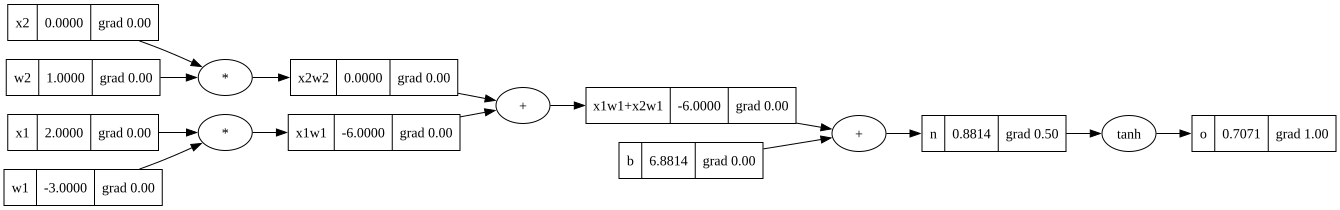

In [35]:
draw_dot(o)

In [36]:
x1w1x2w1.grad = b.grad = 0.5

In [37]:
x1w1.grad = x2w2.grad = 0.5

In [38]:
x2.grad = w2.data *x2w2.grad
w2.grad = x2.data *x2w2.grad

In [39]:
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

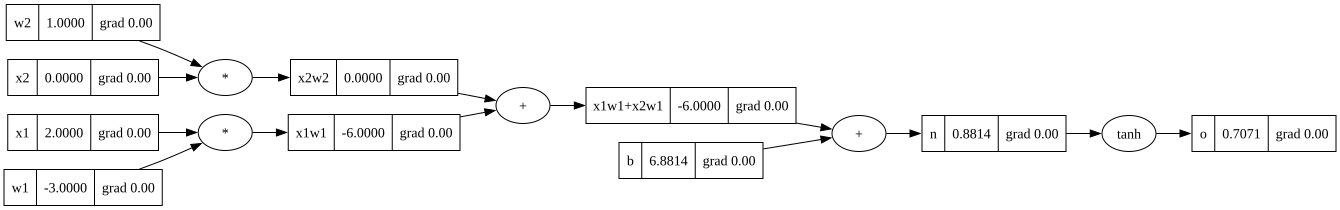

In [40]:
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')
w1 = Value(-3, label='w1')
w2 = Value(1, label = 'w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w1 = x1w1+x2w2; x1w1x2w1.label = 'x1w1+x2w1'
n = x1w1x2w1+b; n.label = 'n'
o = n.tanh()
o.label = 'o'
draw_dot(o)

In [41]:
o.grad = 1
o._backward()

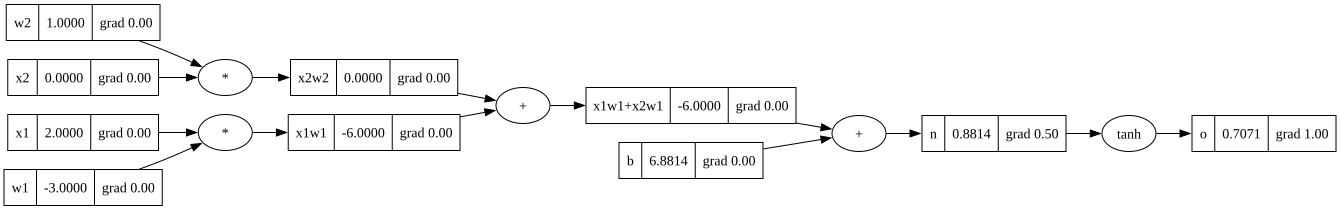

In [42]:
draw_dot(o)

In [43]:
n._backward()

In [44]:
x1w1x2w1._backward()


In [45]:
x1w1._backward()
x2w2._backward()

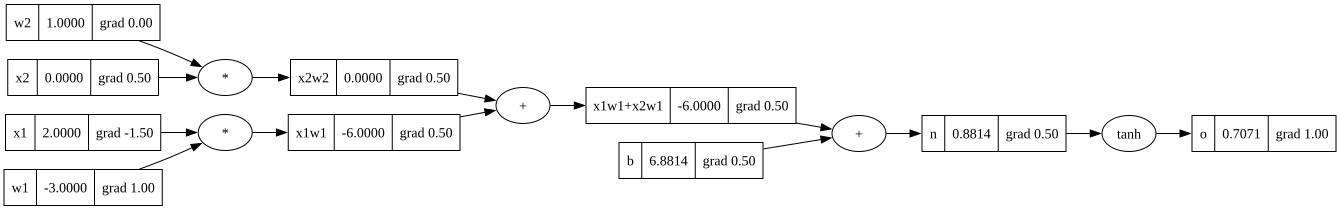

In [46]:
draw_dot(o)

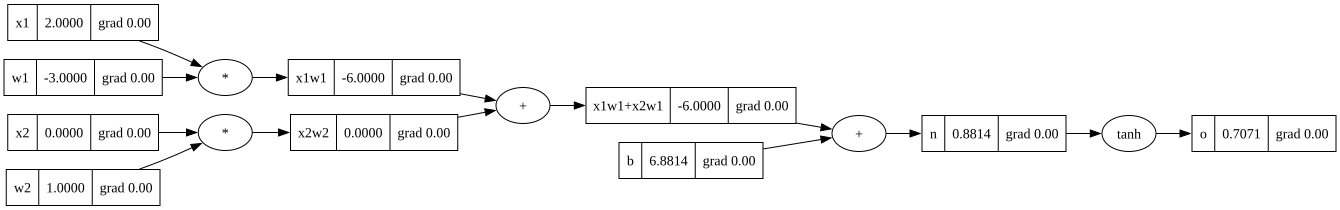

In [47]:
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')
w1 = Value(-3, label='w1')
w2 = Value(1, label = 'w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w1 = x1w1+x2w2; x1w1x2w1.label = 'x1w1+x2w1'
n = x1w1x2w1+b; n.label = 'n'
o = n.tanh()
o.label = 'o'
draw_dot(o)

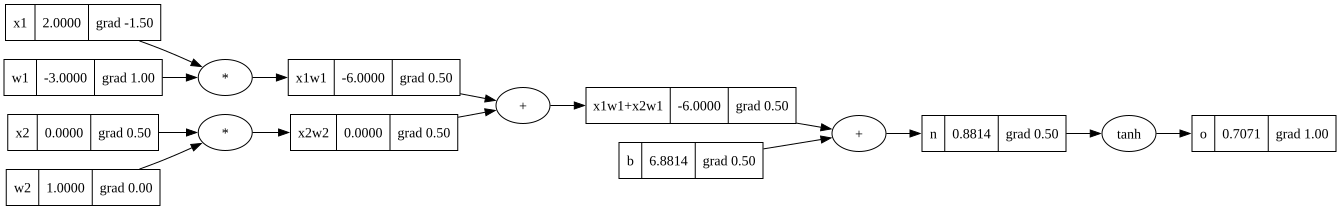

In [48]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)

        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
o.grad = 1
for node in reversed(topo):
    node._backward()
draw_dot(o)

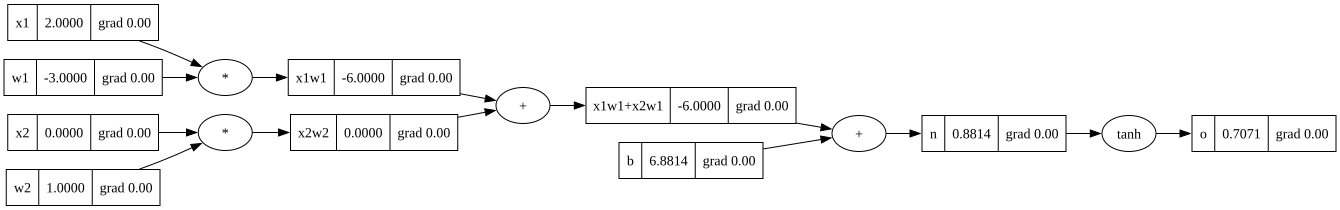

In [49]:
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')
w1 = Value(-3, label='w1')
w2 = Value(1, label = 'w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w1 = x1w1+x2w2; x1w1x2w1.label = 'x1w1+x2w1'
n = x1w1x2w1+b; n.label = 'n'
o = n.tanh()
o.label = 'o'
draw_dot(o)

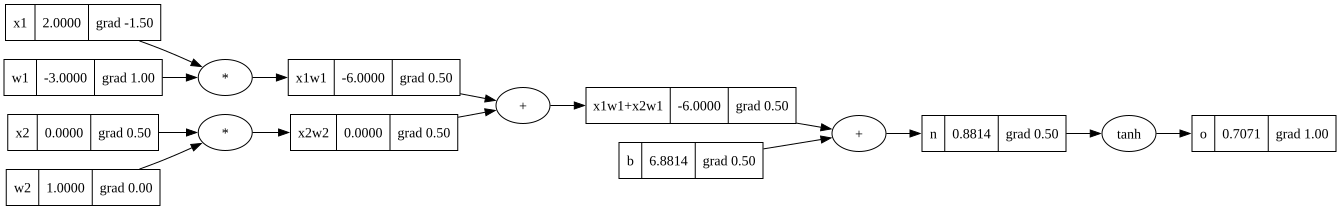

In [50]:
o.backward()
draw_dot(o)

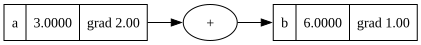

In [51]:
#A BUG
a = Value(3, label='a')
b = a+a ; b.label='b'
b.backward()
draw_dot(b)

In [52]:
# We are seeing the bug coz we are using variable more than 
# once it will not accumulate the grad but it will override it's value 
# on that particular neuron. So, we shopuld accumulate


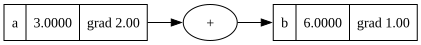

In [53]:
#A BUG
a = Value(3, label='a')
b = a+a ; b.label='b'
b.backward()
draw_dot(b)

In [54]:
a= Value(2)
a+3

Value(data=5)

In [55]:
a= Value(2)
a+3

Value(data=5)

In [56]:
print(a*2) # a.__mul__(2)
print(2*a) # 2.__mul__(a)

Value(data=4)
Value(data=4)


In [57]:
print(2*a)
print(a.exp())

Value(data=4)
Value(data=7.38905609893065)


In [58]:
a/b

Value(data=0.3333333333333333)

In [59]:
# a/b
# a*1/b
# a*b**-1
print(a/b)
# print((a/b).backward())

Value(data=0.3333333333333333)


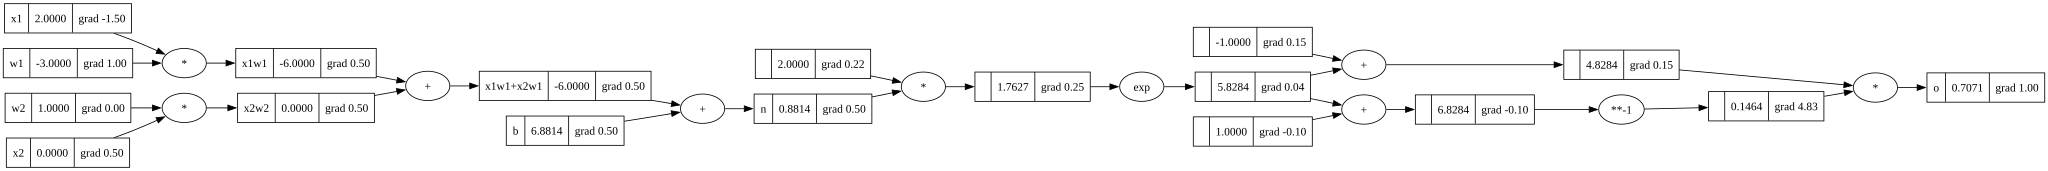

In [60]:
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')
w1 = Value(-3, label='w1')
w2 = Value(1, label = 'w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w1 = x1w1+x2w2; x1w1x2w1.label = 'x1w1+x2w1'
n = x1w1x2w1+b; n.label = 'n'
e = (2*n).exp()

o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)

In [61]:
# SAME THINGY BUT IN PYTORCH 

In [62]:
import torch
x1 = torch.tensor([2.0]).double();    x1.requires_grad = True
x2 = torch.tensor([0]).double();    x2.requires_grad = True
w1 = torch.tensor([-3]).double();   w1.requires_grad = True
w2 = torch.tensor([1]).double();    w2.requires_grad = True
# x1w1 = torch.tensor([0].double());  x1w1.requires_grad = True
b = torch.tensor([6.8813735870195432]).double();    b.requires_grad = True
n = x1*w1+x2*w2 +b
o = torch.tanh(n)
o.retain_grad()
print("===========BEFORE=======")
# print(x2.grad.item())
# print(x1.grad.item())
# print(w1.grad.item())
# print(w2.grad.item())
print(o.item())
o.backward()


print("===========AFTER=======")
print(x2.grad.item())
print(x1.grad.item())
print(w1.grad.item())
print(w2.grad.item())
print(o.grad.item())

===========BEFORE=======
0.7071066904050358
===========AFTER=======
0.5000001283844369
-1.5000003851533106
1.0000002567688737
0.0
1.0


In [63]:
#NEURAL NETWORK

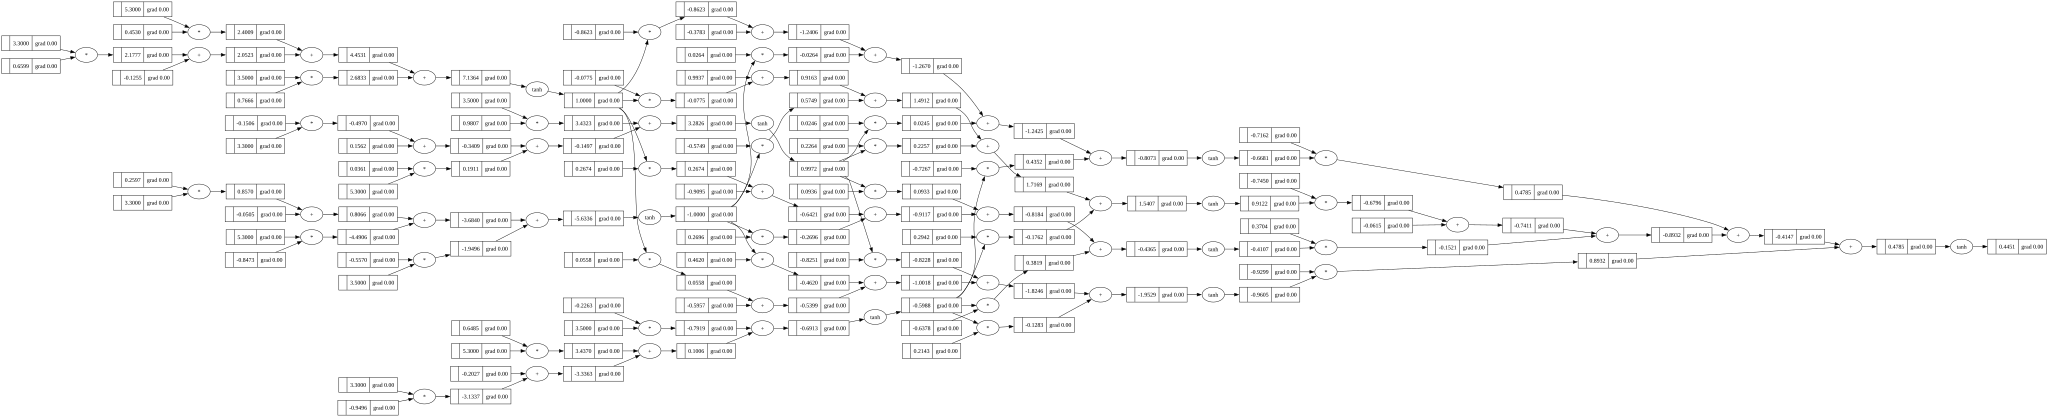

In [255]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi, xi in zip(self.w,x)), self.b)
        out = act.tanh()
        # p
        return out
        

    def parameters(self):
        return self.w + [self.b]



class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        # print(outs)
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for n in self.neurons:
            # print(n.parameters())
            params.extend(n.parameters())

        return params

        #OR
        # return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] +nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        # print(type(x))
        return x
    
    def parameters(self):
        params = []
        for l in self.layers:
            params.extend(l.parameters())
            # params = params.extend(l.parameters())
        # return [p for layer in self.layers for p in layer.parameters()]
        return params

    
x = [3.3, 5.3,3.5]
# n = Neuron(2)
# n(x)
la = [4,4,1]
a = MLP(3,la)
a(x)
draw_dot(a(x))

In [256]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [ 1.0, -1.0, -1.0, 1.0]

rows = len(xs)
cols = len(xs[0])
print(rows, cols)
xs[3][2]

4 3


-1.0

In [195]:
ypred = [a(x) for x in xs]
ypred

[Value(data=-0.8799853003181141),
 Value(data=-0.718662135633907),
 Value(data=-0.6097850086951148),
 Value(data=-0.8172312620005044)]

In [196]:
#THE LOSS

loss= sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
# loss = sum(x.data for x in l1)
loss
# loss

Value(data=7.068092922369281)

In [197]:
loss.backward()

In [198]:
print(a.layers[0].neurons[0].w[0])
print(a.layers[0].neurons[0].w[0].grad)

Value(data=-0.5514840762769555)
0.15930866908715124


In [199]:
len(a.parameters())

41

In [200]:
a.parameters()

[Value(data=-0.5514840762769555),
 Value(data=-0.9391661809304763),
 Value(data=0.6579151850574141),
 Value(data=-0.24378350953191674),
 Value(data=0.021599503642065532),
 Value(data=0.9395434251313952),
 Value(data=-0.6408516032151621),
 Value(data=-0.5443210982705662),
 Value(data=-0.8111388941203264),
 Value(data=0.10532985926278626),
 Value(data=-0.08014878630982936),
 Value(data=-0.5738677577090421),
 Value(data=0.09862147405097055),
 Value(data=0.3295027726772706),
 Value(data=-0.547005560265897),
 Value(data=-0.9056947279815961),
 Value(data=-0.5979272035296657),
 Value(data=-0.12293426825172293),
 Value(data=0.6362411465467064),
 Value(data=-0.6181028896844352),
 Value(data=0.0008943566334507214),
 Value(data=-0.21903426289824068),
 Value(data=-0.1104354246769963),
 Value(data=-0.6553706493678411),
 Value(data=0.43294886997521687),
 Value(data=0.28609210629731563),
 Value(data=0.5842253304608973),
 Value(data=-0.6022130099375937),
 Value(data=-0.1209439184727521),
 Value(data=0

In [202]:
len(a.parameters())

41

In [ ]:
for p in n.parameters():
    p.data += -0.1*p.grad

0

In [204]:
a.layers[0].neurons[0].w[0].data

-0.5514840762769555

In [257]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [ 1.0, -1.0, -1.0, 1.0]

In [259]:
#CUMULATING FORWARD->  BACKWARD -> UPDATE

i = 0
while i!=100:
    ypred = [a(x) for x in xs]

    loss = sum((yout-ygt)**2 for yout, ygt in zip(ypred, ys))
    for p in a.parameters():
        p.grad = 0.0
    print(i+1, loss.data)
    loss.backward()
    for p in a.parameters():
        p.data += 0.05*-p.grad
    i+=1
ypred

1 0.011724027333949621
2 0.011587563888071488
3 0.011454056120610788
4 0.011323410569896428
5 0.011195537646968226
6 0.011070351437814496
7 0.01094776951757484
8 0.010827712775872822
9 0.010710105252510755
10 0.010594873982817254
11 0.010481948851993567
12 0.010371262457855097
13 0.010262749981410017
14 0.0101563490647584
15 0.010051999695834887
16 0.009949644099551442
17 0.009849226634931334
18 0.009750693697852537
19 0.009653993629048865
20 0.00955907662703959
21 0.009465894665683882
22 0.009374401416075762
23 0.009284552172515913
24 0.00919630378231529
25 0.00910961457920063
26 0.009024444320109001
27 0.008940754125172265
28 0.008858506420705339
29 0.008777664885024536
30 0.008698194396934214
31 0.008620060986729372
32 0.008543231789572633
33 0.008467675001112448
34 0.00839335983521845
35 0.008320256483716636
36 0.008248336078015778
37 0.0081775706525218
38 0.008107933109744213
39 0.00803939718700407
40 0.007971937424658546
41 0.0079055291357621
42 0.007840148377089344
43 0.00777577

[Value(data=0.9705994375991784),
 Value(data=-0.9830896205344687),
 Value(data=-0.9492300780928024),
 Value(data=0.9609980343909683)]

In [ ]:

ypred = [a(x) for x in xs]

loss = sum((yout-ygt)**2 for yout, ygt in zip(ypred, ys))
print(loss)
loss.backward()
for p in a.parameters():
    # p.grad = 0
    p.data += -0.1*p.grad

ypred

